# EDA & WordCloud 


## Exploration Data Analysis

In [ ]:
pip install -r "requirements.txt"

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for accelerate from https://files.pythonhosted.org/packages/a8/db/253133d7e7cb40d3af384bb2f5c0b4a2b7fdcffbc95c688cc67a20a3c103/accelerate-1.14.0-py3-none-any.whl.metadata
  Obtaining dependency information for bertopic from https://files.pythonhosted.org/packages/81/d2/2eb2fec18b3d2cf487d5d1d9b484c6483c7f0f1a3c6f64e2bb9cb7972a3f/bertopic-0.17.4-py3-none-any.whl.metadata
  Obtaining dependency information for gensim from https://files.pythonhosted.org/packages/10/c3/7e22d6f7d88c4ea6a3a84481f00538252659d285713c3b7e2e1537b0e7e1/gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for hdbscan from https://files.pythonhosted.org/packages/13/8d/eec0040bd273c9e43409672c8cec1956775aca3ebafad8a9e3f5d25cfd80/hdbscan-0.8.44-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/package

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
celery 5.4.0 requires click-plugins>=1.1.1, which is not installed.
sqltrie 0.11.0 requires orjson; implementation_name == "cpython", which is not installed.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer


# Tambahkan ini — import Sastrawi setelah install
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [16]:
#LOAD DATA
data_new = pd.read_csv("Data/data_banjir.csv", sep=",", encoding="utf-8")
print(data_new.columns)
data_new.tail()

Index(['text', 'clean_text', 'created_at', 'keyword', 'processed_text',
       'sentimen', 'label', 'emoticon'],
      dtype='str')


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon
8643,"Definisi ""membaik"" dalam konteks bencana BNPB ...",definisi membaik dalam konteks bencana bnpb bi...,2025-11-29,banjir Sumatera Barat,definisi baik konteks bencana bnpb biasa rujuk...,negatif,0.0,NaN
8644,Beberapa hari terakhir ini saudara-saudara kit...,beberapa hari terakhir ini saudara saudara kit...,2025-11-29,banjir Sumatera Barat,beberapa hari akhir saudara saudara aceh sumat...,netral,1.0,NaN
8645,BNPB ungkapkan alasan mengapa bencana banjir d...,bnpb ungkapkan alasan mengapa bencana banjir d...,2025-11-29,banjir Sumatera Barat,bnpb ungkap alas bencana banjir wilayah sumate...,netral,1.0,NaN
8646,Markas Besar Tentara Nasional Indonesia (Mabes...,markas besar tentara nasional indonesia mabes ...,2025-11-29,banjir Sumatera Barat,markas besar tentara nasional indonesia mabes ...,positif,2.0,NaN
8647,𝗗𝗮𝗿𝗺𝗮𝘄𝗮𝗻 𝗣𝗿𝗮𝘀𝗼𝗱𝗷𝗼 𝗨𝗻𝗴𝗸𝗮𝗽 𝗟𝗮𝗻𝗴𝗸𝗮𝗵 𝗣𝗟𝗡 𝗔𝘁𝗮𝘀𝗶 𝗟𝗶𝘀...,armawan rasodjo ngkap angkah tasi istrik erput...,2025-11-29,banjir Sumatera Barat,armawan rasodjo ngkap angkah tas istrik erputu...,negatif,0.0,𝗸𝗷𝗗𝗔𝗪𝗴𝗵𝗱𝘁𝘀𝗲𝗟𝗽𝗰𝗶𝗺𝘄𝗨𝗧𝘆𝗹𝗮𝗿𝗼𝗣𝗡𝘂𝗕𝗻


In [17]:
#Tabel distribusi sentimen
distribusi = data_new['sentimen'].value_counts().reset_index()
distribusi.columns = ['Sentimen', 'Jumlah']
distribusi['Persentase'] = (distribusi['Jumlah'] / distribusi['Jumlah'].sum() * 100).round(2)
total = sum(distribusi['Jumlah'])

df_distribusi = pd.DataFrame(distribusi)
display(df_distribusi)
print("total data:", total)

,Sentimen,Jumlah,Persentase
0,negatif,4843,56.00
1,positif,2340,27.06
2,netral,1465,16.94


total data: 8648


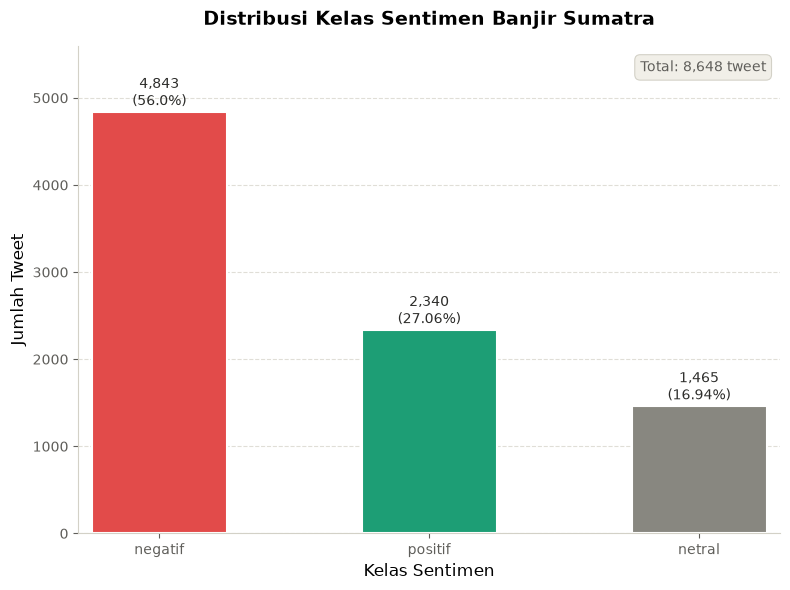

Chart berhasil disimpan!


In [18]:
# Warna
colors = ['#E24B4A', '#1D9E75', '#888780']

# =====================================================
# BAR CHART
# =====================================================
fig, ax = plt.subplots(figsize=(8, 6))
df = df_distribusi.sort_values(by='Jumlah', ascending=False)
x = np.arange(len(df['Sentimen']))
width = 0.5  # dinaikkan

bars = ax.bar(
    x, df['Jumlah'],
    color=colors, width=width,
    edgecolor='white', linewidth=1.5
)

# Label di atas bar
for bar, jml, pct in zip(bars, df['Jumlah'], df['Persentase']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{jml:,}\n({pct}%)',
        ha='center', va='bottom',
        fontsize=10, color='#2C2C2A'
    )

# Total di pojok kanan atas
ax.text(
    0.98, 0.97,
    f'Total: {total:,} tweet',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=10, color='#5F5E5A',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#F1EFE8',
              edgecolor='#D3D1C7',
              linewidth=0.8)
)

ax.set_title('Distribusi Kelas Sentimen Banjir Sumatra',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Sentimen', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df['Sentimen'])
ax.set_xlim(-0.3, 2.3)  # dipersempit
ax.set_ylim(0, 5600)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D3D1C7')
ax.spines['bottom'].set_color('#D3D1C7')
ax.yaxis.grid(True, color='#D3D1C7',
              linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(colors='#5F5E5A')

plt.tight_layout()
plt.savefig('Output/Wordcloud & Distribusi Data/distribusi_sentimen.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Chart berhasil disimpan!")

In [19]:
from itables import show

#cek emoticon
print("Jumlah data dengan emoticon : ", data_new['emoticon'].notna().sum())

print("\nContoh data dengan emoticon:")
show(data_new.loc[data_new['emoticon'].notna(), ['text', 'emoticon']].sort_index())

print("\nFrekuensi emoticon:")
show(data_new['emoticon'].dropna().value_counts())

Jumlah data dengan emoticon :  165

Contoh data dengan emoticon:



Frekuensi emoticon:


In [20]:
from Prepocessing.emoji_dict import emoji_dict

def convert_emoticon(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Urutkan emoji paling panjang dulu agar kombinasi seperti ❤️‍🩹 tidak pecah
    for emo in sorted(emoji_dict.keys(), key=len, reverse=True):
        text = text.replace(emo, emoji_dict[emo])

    text = re.sub(r"\s+", " ", text).strip()

    return text

#Gabungkan text dan emoticon
data_new['emoticon'] = data_new['emoticon'].fillna('')
data_new['text_with_emoticon_raw'] = (data_new['text'].astype(str) + ' ' + data_new['emoticon'].astype(str))
data_new['text_with_emoticon'] = data_new['text_with_emoticon_raw'].apply(convert_emoticon)

print("Contoh hasil gabungan khusus data yang punya emoticon:")
show(data_new.loc[data_new['emoticon'] != '',['text', 'emoticon', 'text_with_emoticon_raw', 'text_with_emoticon', 'sentimen']].sort_index())

Contoh hasil gabungan khusus data yang punya emoticon:


## WordCloud

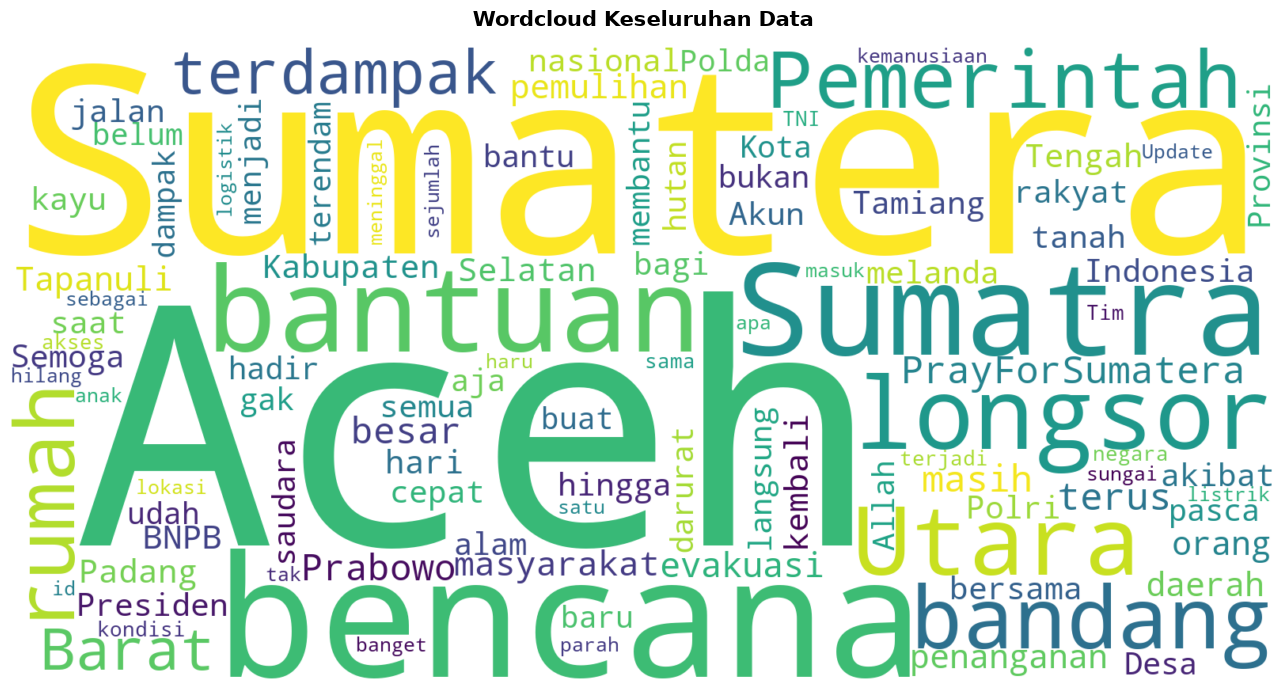

Wordcloud keseluruhan disimpan!


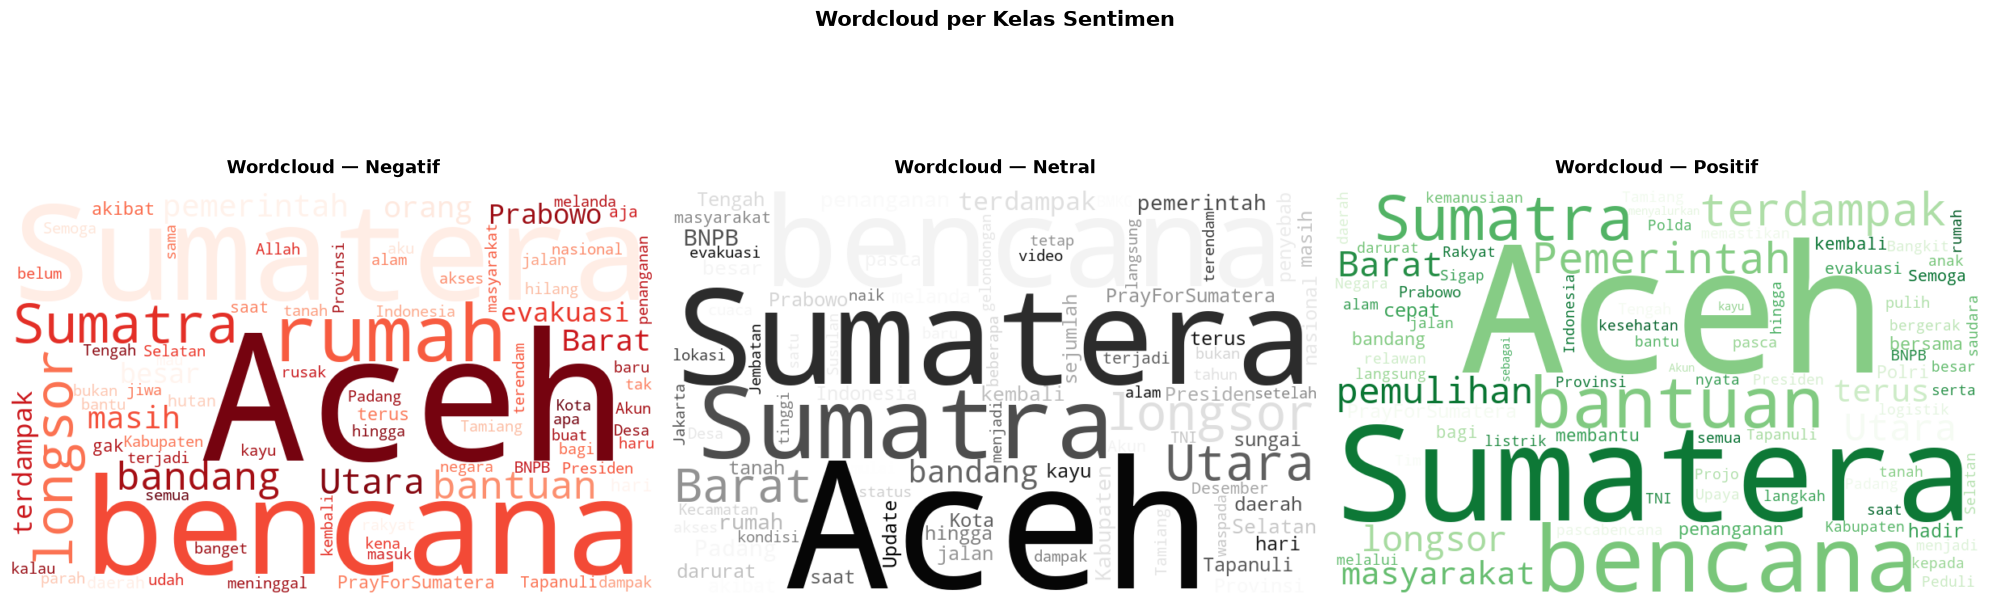

Wordcloud per kelas disimpan!


In [21]:
from Prepocessing.stopwords_wordcloud import custom_stopwords
# =====================================================
# WORDCLOUD KESELURUHAN
# =====================================================

# PAKAI TEXT + EMOTICON
teks_all = ' '.join(data_new['text_with_emoticon'])

wc_all = WordCloud(
    width=1600,
    height=800,
    max_words=100,
    background_color='white',
    colormap='viridis',
    stopwords=custom_stopwords,
    collocations=False,
    min_font_size=10
).generate(teks_all)

plt.figure(figsize=(14, 7))

plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Wordcloud Keseluruhan Data',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    'Output/Wordcloud & Distribusi Data/wordcloud_keseluruhan.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Wordcloud keseluruhan disimpan!")

# =====================================================
# WORDCLOUD PER KELAS SENTIMEN
# =====================================================

warna = {
    'negatif': 'Reds',
    'netral' : 'Greys',
    'positif': 'Greens'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, sentimen in zip(
    axes,
    ['negatif', 'netral', 'positif']
):

    teks = ' '.join(
        data_new[
            data_new['sentimen'] == sentimen
        ]['text_with_emoticon']
    )

    wc = WordCloud(
        width=800,
        height=500,
        max_words=80,
        background_color='white',
        colormap=warna[sentimen],
        stopwords=custom_stopwords,
        collocations=False,
        min_font_size=10
    ).generate(teks)

    ax.imshow(wc, interpolation='bilinear')

    ax.axis('off')

    ax.set_title(
        f'Wordcloud — {sentimen.capitalize()}',
        fontsize=13,
        fontweight='bold',
        pad=12
    )

plt.suptitle(
    'Wordcloud per Kelas Sentimen',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'Output/Wordcloud & Distribusi Data/wordcloud_per_kelas.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Wordcloud per kelas disimpan!")

-----

# PROCESSING DATA LSTM & INDOBERT

## Prepocessing LSTM

In [22]:
from Prepocessing.normalisasi_dict import normalisasi_dict
from Prepocessing.stopwords_lstm_processing import keep_words

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())
stopwords = stopwords - keep_words
stemmer = StemmerFactory().create_stemmer()
stem_cache = {}

def preprocess_lstm(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Hapus URL dan mention
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # Hashtag tetap ambil katanya
    text = re.sub(r"#(\w+)", r"\1", text)

    # Hapus noise hasil scraping
    text = re.sub(r'\bcom\b', '', text)
    text = re.sub(r'\brb\b', '', text)
    text = re.sub(r'\btampilkan\b', '', text)
    text = re.sub(r'\bmembalas\b', '', text)

    # Hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenizing
    tokens = text.split()

    # Normalisasi
    tokens = [normalisasi_dict.get(w, w) for w in tokens]

    # Stopword removal
    tokens = [w for w in tokens if w not in stopwords]

    # Stemming
    result = []
    for word in tokens:
        if word not in stem_cache:
            stem_cache[word] = stemmer.stem(word)
        result.append(stem_cache[word])

    return ' '.join(result)



## Prepocessing IndoBERT

In [23]:
def preprocess_bert(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Hapus URL dan mention
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    # Hashtag tetap ambil katanya
    text = re.sub(r"#(\w+)", r"\1", text)

    # Rapikan simbol yang sering mengganggu
    text = re.sub(r"[:]", " ", text)

    # Rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [24]:
from pathlib import Path
from time import perf_counter

data_path = Path("Data/data_preprocessed_with_emoticon.csv")

if data_path.exists():
    print("Data sudah ada, tidak perlu preprocessing lagi.")
    df = pd.read_csv(data_path)

else:
    start = perf_counter()

    print("Preprocessing LSTM/BiLSTM...")
    data_new["clean_text_lstm"] = (
        data_new["text_with_emoticon"].apply(preprocess_lstm)
    )

    print("Preprocessing IndoBERTweet-LoRA...")
    data_new["text_bert"] = (
        data_new["text_with_emoticon"].apply(preprocess_bert)
    )

    duration = perf_counter() - start
    print(f"Selesai dalam {duration:.2f} detik")

    #Encode label
    label_map = {
        'negatif': 0,
        'netral': 1,
        'positif': 2
    }

    data_new['label'] = data_new['sentimen'].map(label_map).astype(int)
    df = data_new.copy()

    # Buat folder Data jika belum tersedia
    data_path.parent.mkdir(parents=True, exist_ok=True)

    # Simpan agar preprocessing tidak perlu diulang
    df.to_csv(data_path, index=False)
    print("Data hasil preprocessing dengan emoticon berhasil disimpan.")    

print(df.columns)
show(df)

Data sudah ada, tidak perlu preprocessing lagi.
Index(['text', 'clean_text', 'created_at', 'keyword', 'processed_text',
       'sentimen', 'label', 'emoticon', 'text_with_emoticon_raw',
       'text_with_emoticon', 'clean_text_lstm', 'text_bert'],
      dtype='str')


___

# Split Data

In [25]:
from sklearn.model_selection import train_test_split
from pathlib import Path
import pickle   

path_split_data = Path("Data/split_data.pkl")

if path_split_data.exists():
    print("Data split sudah ada, tidak perlu split lagi." "\n")
    with open(path_split_data, "rb") as f:
        data = pickle.load(f)

    # Ekstrak data dari dictionary
    df_train = data["df_train"]
    df_test = data["df_test"]
    X_train_lstm = data["X_train_lstm"]
    X_test_lstm = data["X_test_lstm"]
    X_train_bert = data["X_train_bert"]
    X_test_bert = data["X_test_bert"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    X_training_lstm = data["X_training_lstm"]
    X_validation_lstm = data["X_validation_lstm"]
    y_training_lstm = data["y_training_lstm"]
    y_validation_lstm = data["y_validation_lstm"]
else :
    print("Membagi data menjadi train dan test...")
    # =====================================================
    # 11. SPLIT DATA (Train-Test Split)
    # =====================================================
    # 1. Split DataFrame secara langsung
    df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

    # 2. Ekstrak fitur & target, lalu reset index untuk LSTM
    X_train_lstm = df_train["clean_text_lstm"].reset_index(drop=True)
    X_test_lstm = df_test["clean_text_lstm"].reset_index(drop=True)
    
    X_train_bert = df_train["text_bert"].reset_index(drop=True)
    X_test_bert = df_test["text_bert"].reset_index(drop=True)

    y_train = df_train["label"].reset_index(drop=True)
    y_test = df_test["label"].reset_index(drop=True)

    X_training_lstm, X_validation_lstm, y_training_lstm, y_validation_lstm = train_test_split(
        X_train_lstm, y_train, test_size=0.1, stratify=y_train, random_state=32)
    print("Data berhasil dibagi menjadi train dan test.")

    # =====================================================
    # 12. SIMPAN SPLIT DATA
    # =====================================================
    with open(path_split_data, 'wb') as f:
        pickle.dump({
            'df_train'    : df_train,
            'df_test'     : df_test,
            'X_train_lstm': X_train_lstm,
            'X_test_lstm' : X_test_lstm,''
            'X_train_bert': X_train_bert,
            'X_test_bert' : X_test_bert,
            'y_train'     : y_train,
            'y_test'      : y_test,
            'X_training_lstm' : X_training_lstm,
            'X_validation_lstm' : X_validation_lstm,
            'y_training_lstm' : y_training_lstm,
            'y_validation_lstm' : y_validation_lstm
        }, f)

    print("Split data berhasil disimpan ke split_data.pkl!" )


# 3. Evaluasi Distribusi Data]
print(f"\nTotal Data Train : {len(df_train)}")
print("Distribusi Data Train:\n", df_train["sentimen"].value_counts().sort_index(), "\n")

print(f"Total Data Test  : {len(df_test)}")
print("Distribusi Data Test:\n", df_test["sentimen"].value_counts().sort_index(), "\n")

Data split sudah ada, tidak perlu split lagi.


Total Data Train : 6918
Distribusi Data Train:
 sentimen
negatif    3874
netral     1172
positif    1872
Name: count, dtype: int64 

Total Data Test  : 1730
Distribusi Data Test:
 sentimen
negatif    969
netral     293
positif    468
Name: count, dtype: int64 

